In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from typing import Dict, List, Tuple
from training.data_loading import *
from training.loss_funcs import *

print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}") # I have a 3090
    torch.set_float32_matmul_precision("medium")
    print("float32 matmul precision set to 'medium'")

# ── Moirai / training-stack imports ──────────────────────────────────────────
# pip install "uni2ts @ git+https://github.com/SalesforceAIResearch/uni2ts.git" gluonts mlflow
# Requires Python >= 3.10 (uni2ts 2.x)
import os
import copy
from tqdm.notebook import tqdm

import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from gluonts.dataset.common import ListDataset

# uni2ts 2.x: MoiraiModule owns from_pretrained; MoiraiForecast/MoiraiFinetune take module=
from uni2ts.model.moirai import MoiraiForecast, MoiraiFinetune
from uni2ts.model.moirai.module import MoiraiModule

import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, TQDMProgressBar

import mlflow
import mlflow.pytorch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device           : {DEVICE}")


PyTorch version  : 2.6.0+cu124
CUDA available   : True
GPU              : NVIDIA GeForce RTX 3090
float32 matmul precision set to 'medium'
Device           : cuda


In [2]:
weather_cols_to_keep = [
    "temperature_2m",
    "precipitation",
    "cloud_cover",
    "wind_speed_10m",
    "shortwave_radiation",
    "direct_normal_irradiance"
]

other_cols = [ # these are not static
    'dam_price', 'buy_bm_price', 'sell_bm_price',
    'max_power', 'max_solar', 'max_ev'
]

cat_columns = [
    'eic_code', 'dso_desc', 'station_type', 'oblast',
    'Month', 'Day', 'Hour', 'day_of_week', 'season'
]

static_cols = [
    'latitude', 'longitude', 'eic_code', 'dso_desc', 'station_type', 'oblast'
]

calendar_cols = [
    'Month', 'Day', 'Hour', 'day_of_week', 'season'
]

time_cols = ['datetime', 'time_idx']

FUTURE_REALS = weather_cols_all + calendar_cols + static_cols + other_cols
print(f"y col is: {Y_COL}, group col is: {GROUP_COL}\n"
      f"features: {FUTURE_REALS}")

y col is: sum_of_kWh, group col is: eic_code
features: ['temperature_2m', 'apparent_temperature', 'dew_point_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'shortwave_radiation', 'diffuse_radiation', 'direct_normal_irradiance', 'Month', 'Day', 'Hour', 'day_of_week', 'season', 'latitude', 'longitude', 'eic_code', 'dso_desc', 'station_type', 'oblast', 'dam_price', 'buy_bm_price', 'sell_bm_price', 'max_power', 'max_solar', 'max_ev']


In [3]:
# this data has a data column and categorical columns are kept intact and will need to be handled.
# "time_idx" is already built in train, val and test and is continuous through them
print("Loading train …")
train = load_and_prepare(TRAIN_PATH_WITH_DATETME)

print("Loading val   …")
val = load_and_prepare(VAL_PATH_WITH_DATETME)

print("Loading test  …")
test = load_and_prepare(TEST_PATH_WITH_DATETME)

print(f"train: {train.shape}")
print(f"val : {val.shape}")
print(f"test: {test.shape}")

Loading train …
Loading val   …
Loading test  …
train: (4586151, 38)
val : (293880, 38)
test: (295430, 38)


In [4]:
# # If a model cant handle categorical columns natively, or through embedings use this data
# # It has no datetime column and all columns are numeric, as all cat column were ohe
# # GROUP_COL is the only exception, and is not ohe. Ohe it before training
# print("Loading train …")
# train = load_and_prepare(TRAIN_PATH_OHE)
#
# print("Loading val   …")
# val = load_and_prepare(VAL_PATH_OHE)
#
# print("Loading test  …")
# test = load_and_prepare(TEST_PATH_OHE)
#
# print(f"train: {train.shape}")
# print(f"val  : {val.shape}")
# print(f"test : {test.shape}")

In [5]:
# this cell samples locations, I'll use it if training takes too long, otherwise don't touch it

TARGET_STATIONS = 395

station_stats = (
    train.groupby(GROUP_COL)
    .agg(rows=(Y_COL, "count"))
    .reset_index()
    .sort_values("rows", ascending=False)
)

sampled_stations = station_stats.sample(
    n=TARGET_STATIONS, random_state=42
)[GROUP_COL].values

print(f"Stations: {len(sampled_stations)}")

train = train[train[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
val   = val[val[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
test  = test[test[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)

print(f"Train rows : {len(train):,}")
print(f"Val rows   : {len(val):,}")
print(f"Test rows  : {len(test):,}")

Stations: 395
Train rows : 4,586,151
Val rows   : 293,880
Test rows  : 295,430


In [6]:
training_cutoff = train["time_idx"].max()
val_cutoff      = val["time_idx"].max()
test_cutoff     = test["time_idx"].max()

print(f"training cutoff : {training_cutoff}")
print(f"val cutoff      : {val_cutoff}")
print(f"test cutoff     : {test_cutoff}")

training cutoff : 13125
val cutoff      : 13869
test cutoff     : 14617


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Moirai config — sizing and training hyperparameters
# ─────────────────────────────────────────────────────────────────────────────
# Moirai is a *foundation* time-series model (Salesforce, ICML 2024). It works
# in patch space: each window of length CONTEXT_LEN + PRED_LEN is reshaped into
# (n_patches, patch_size). PATCH_SIZE must divide CONTEXT_LEN + PRED_LEN.

MODEL_ID    = "Salesforce/moirai-1.1-R-small"   # small=91M / base=236M / large=311M
CONTEXT_LEN = 168    # 1-week look-back (hourly)
PRED_LEN    = 48     # 48-hour forecast horizon (matches val/test rolling)
PATCH_SIZE  = 8      # (168 + 48) / 8 = 27 patches; last 6 are prediction patches
NUM_SAMPLES = 100    # Monte-Carlo samples for the predictive distribution at inference

# Fine-tuning
TRAIN_STRIDE = 24    # one window per day — fast, diverse coverage
BATCH_SIZE   = 64
EPOCHS       = 10
LR           = 1e-4
WEIGHT_DECAY = 1e-2
SMAPE_WEIGHT = 0.1   # SMAPE regulariser in the money_pct training loss
NUM_WORKERS  = 0     # 0 on Windows / Jupyter (avoids multiprocessing deadlock)
SEED         = 42

CKPT_DIR  = "../../checkpoints"
SAVE_PATH = os.path.join(CKPT_DIR, "moirai_finetuned_money.pt")
os.makedirs(CKPT_DIR, exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)


## Moirai dataset preparation

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Moirai-specific dataset preparation
# ─────────────────────────────────────────────────────────────────────────────
# Moirai (uni2ts v2.x) consumes data in PATCH form, not raw (T, 1) tensors.
# Each sample is a dict whose tensors all have a leading patch dim of size P:
#   target          : (P, MAX_PATCH=128) float  — values, zero-padded after patch_size
#   observed_mask   : (P, MAX_PATCH)     bool   — True where target is real data
#   prediction_mask : (P,)               bool   — True for the last n_pred_patches
#   time_id         : (P,)               long   — patch position 0..P-1
#   variate_id      : (P,)               long   — variate index (0 for univariate)
#   patch_size      : (P,)               long   — patch size used for this sample
#   sample_id       : (P,)               long   — segment id (single segment → 0)
#
# This Moirai example uses a UNIVARIATE target (Y_COL only) as the model
# INPUT — exogenous reals can technically be passed via past_feat_dynamic_real
# / feat_dynamic_real, but the dataset class shape changes substantially and
# the working uni2ts template does not use them. The foundation model
# already encodes calendar effects implicitly.
#
# The three price columns ARE carried through the dataset alongside the
# target, but as auxiliary tensors that bypass MoiraiModule.forward and feed
# directly into the money_pct training loss. The model itself never sees
# them — they only enter through the loss.
# Categorical columns are NOT used as model inputs in this univariate setup;
# eic_code is used only to split per-series windows.

def build_series_dict(df: pd.DataFrame) -> Dict[str, dict]:
    out = {}
    for eic, grp in df.groupby(GROUP_COL):
        grp = grp.sort_values("time_idx")
        out[eic] = {
            "values":        grp[Y_COL].values.astype(np.float32),
            "time_idx":      grp["time_idx"].values.astype(np.int64),
            "datetime":      grp["datetime"].values,
            "dam_price":     grp["dam_price"].values.astype(np.float32),
            "sell_bm_price": grp["sell_bm_price"].values.astype(np.float32),
            "buy_bm_price":  grp["buy_bm_price"].values.astype(np.float32),
        }
    return out


def fill_nan(arr: np.ndarray) -> np.ndarray:
    if not np.isnan(arr).any():
        return arr
    return (
        pd.Series(arr)
        .interpolate(method="linear", limit_direction="both")
        .values.astype(np.float32)
    )


# Continuous full-history view for rolling inference (val + test windows need
# train-side context, so we concat). time_idx is already continuous across
# splits per the project setup.
full_df = (
    pd.concat([train, val, test], ignore_index=True)
    .sort_values([GROUP_COL, "time_idx"])
    .reset_index(drop=True)
)

train_series = build_series_dict(train)
full_series  = build_series_dict(full_df)

lengths = [len(v["values"]) for v in train_series.values()]
print(f"Stations         : {len(train_series)}")
print(f"Train series len : min={min(lengths)}, max={max(lengths)}, mean={np.mean(lengths):.0f}")


class MoiraiWindowDataset(Dataset):
    """Sliding-window dataset producing the patch-shaped tensors MoiraiFinetune expects.

    Also carries the **per-hour price triplet** (dam, sell, buy) and the
    per-window normalization stats (mu, sig) so the money_pct loss in the
    custom training_step can de-normalize Moirai's normalized predictions
    back into kWh and compute the financial cost against real prices.
    """

    MAX_PATCH = 128  # moirai-1.1-R fixed max patch size — pad shorter patches to this width

    def __init__(self, series_dict, context_len, pred_len, stride, patch_size,
                 holdout_tail: int = 0, tail_only: bool = False):
        """
        holdout_tail : reserve this many hours at the end of each series for a
                       held-out loss-eval set; training windows will not span
                       those hours.
        tail_only    : if True, emit ONLY one window per station — the last
                       seq_len hours of the available history. Used to build
                       the held-out validation loader for per-epoch logging.
        """
        self.context_len    = context_len
        self.pred_len       = pred_len
        self.seq_len        = context_len + pred_len
        self.patch_size     = patch_size
        self.n_patches      = self.seq_len // patch_size
        self.n_pred_patches = pred_len // patch_size

        # Each entry: (values_seq, dam_seq, sell_seq, buy_seq), all length seq_len
        self.windows: List[Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]] = []
        for eic, data in series_dict.items():
            ts   = fill_nan(data["values"])
            dam  = fill_nan(data["dam_price"])
            sell = fill_nan(data["sell_bm_price"])
            buy  = fill_nan(data["buy_bm_price"])
            if len(ts) < self.seq_len:
                continue

            if tail_only:
                # Single window covering the last seq_len hours of this station.
                s = len(ts) - self.seq_len
                self.windows.append((
                    ts[s:].copy(), dam[s:].copy(), sell[s:].copy(), buy[s:].copy(),
                ))
            else:
                # Sliding training windows; stop before the holdout tail so
                # validation hours never appear inside any training window.
                last_start = len(ts) - self.seq_len - holdout_tail
                if last_start < 0:
                    continue
                for s in range(0, last_start + 1, stride):
                    e = s + self.seq_len
                    self.windows.append((
                        ts[s:e].copy(), dam[s:e].copy(), sell[s:e].copy(), buy[s:e].copy(),
                    ))

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        seq, dam, sell, buy = self.windows[idx]
        P, ps = self.n_patches, self.patch_size

        # Per-instance normalization using context-window statistics only.
        # We store mu/sig so the loss can invert this and compute money_pct in
        # real kWh / real currency, not in normalized units.
        ctx = seq[: self.context_len]
        mu  = float(ctx.mean())
        sig = max(float(ctx.std()), 1e-5)
        seq_n = (seq - mu) / sig

        target = torch.zeros(P, self.MAX_PATCH, dtype=torch.float32)
        target[:, :ps] = torch.from_numpy(seq_n.reshape(P, ps)).float()

        observed_mask = torch.zeros(P, self.MAX_PATCH, dtype=torch.bool)
        observed_mask[:, :ps] = True

        prediction_mask = torch.zeros(P, dtype=torch.bool)
        prediction_mask[-self.n_pred_patches :] = True

        # Reshape prices to (P, ps) so they line up with target / observed_mask
        # exactly, then zero-pad to MAX_PATCH the same way as target.
        def _to_patch(arr):
            t = torch.zeros(P, self.MAX_PATCH, dtype=torch.float32)
            t[:, :ps] = torch.from_numpy(arr.reshape(P, ps)).float()
            return t

        return {
            "target":          target,
            "observed_mask":   observed_mask,
            "prediction_mask": prediction_mask,
            "time_id":         torch.arange(P, dtype=torch.long),
            "variate_id":      torch.zeros(P, dtype=torch.long),
            "patch_size":      torch.full((P,), ps, dtype=torch.long),
            "sample_id":       torch.zeros(P, dtype=torch.long),
            # Auxiliary tensors used by money_pct_torch in MoneyLossMoiraiFinetune.
            # Moirai itself ignores keys it doesn't know about.
            "dam_price":       _to_patch(dam),     # (P, MAX_PATCH)
            "sell_bm_price":   _to_patch(sell),    # (P, MAX_PATCH)
            "buy_bm_price":    _to_patch(buy),     # (P, MAX_PATCH)
            "norm_mu":         torch.tensor(mu,  dtype=torch.float32),
            "norm_sig":        torch.tensor(sig, dtype=torch.float32),
        }


def collate_moirai(batch):
    return {k: torch.stack([b[k] for b in batch]) for k in batch[0]}


train_ds = MoiraiWindowDataset(
    train_series, CONTEXT_LEN, PRED_LEN, TRAIN_STRIDE, PATCH_SIZE,
    holdout_tail=CONTEXT_LEN + PRED_LEN,   # reserve the last seq_len hours per station
)
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_moirai, num_workers=NUM_WORKERS, pin_memory=True,
)

# Held-out per-epoch loss-eval set: the last seq_len hours of each station's
# training history. Used ONLY for the per-epoch print of money_pct / smape on
# unseen data — the project's val/test splits remain reserved for the rolling
# inference cells below.
val_loss_ds = MoiraiWindowDataset(
    train_series, CONTEXT_LEN, PRED_LEN, TRAIN_STRIDE, PATCH_SIZE,
    tail_only=True,
)
val_loss_loader = DataLoader(
    val_loss_ds, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_moirai, num_workers=NUM_WORKERS, pin_memory=True,
)
print(f"Training windows : {len(train_ds):,}")
print(f"Val-loss windows : {len(val_loss_ds):,}  (one tail window per station)")
print(f"Batches / epoch  : {len(train_loader):,}")
print(f"Patches / sample : {train_ds.n_patches}  (pred patches: {train_ds.n_pred_patches})")


Stations         : 395
Train series len : min=1365, max=13126, mean=11611
Training windows : 184,046
Val-loss windows : 395  (one tail window per station)
Batches / epoch  : 2,876
Patches / sample : 27  (pred patches: 6)


## Money-loss wrapper (differentiable PyTorch)

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Differentiable PyTorch wrappers around money_pct and SMAPE
# ─────────────────────────────────────────────────────────────────────────────
# Mirrors loss_funcs.money_pct exactly:
#   • prices are per-MWh → divided by 1000 before multiplying with kWh
#   • NO tolerance band — every kWh of deviation is penalised
#   • over-prediction (diff > 0): rebate at sell_bm_price on the excess
#   • under-prediction (diff < 0): pay buy_bm_price for the deficit
#   • result is POOLED: sum(real_spend − min_spend) / (sum(min_spend) / 100)
# Pooled aggregation means a single value per batch, NOT a mean of per-sample
# percentages. This matches your project's reference and keeps train/val/test
# numbers directly comparable to the rolling_eval cell.

def money_pct_torch(
    y_true: torch.Tensor,         # (N,) — actual kWh
    y_pred: torch.Tensor,         # (N,) — predicted kWh
    dam_price: torch.Tensor,      # (N,) — day-ahead price (per MWh)
    sell_bm_price: torch.Tensor,  # (N,) — balancing sell-back price (per MWh)
    buy_bm_price: torch.Tensor,   # (N,) — balancing buy price (per MWh)
    eps: float = 1e-6,
) -> torch.Tensor:
    # Per-MWh → per-kWh
    p_dam  = dam_price     / 1000.0
    p_sell = sell_bm_price / 1000.0
    p_buy  = buy_bm_price  / 1000.0

    min_spend      = y_true * p_dam            # perfect-foresight DAM cost
    ordered_amount = y_pred * p_dam            # what we actually order at DAM
    diff           = y_pred - y_true

    # diff > 0 → over-ordered, sell back excess at sell_bm_price (cost ↓)
    # diff < 0 → under-ordered, buy deficit at buy_bm_price (cost ↑)
    zero       = torch.zeros_like(diff)
    real_spend = (
        ordered_amount
        - torch.where(diff > 0, p_sell * diff, zero)
        - torch.where(diff < 0, p_buy  * diff, zero)
    )

    # Pooled cost ratio, expressed as a percentage. Matches loss_funcs.money_pct.
    return (real_spend - min_spend).sum() / min_spend.sum().clamp_min(eps) * 100.0


def smape_torch(
    y_true: torch.Tensor,   # (N,) — real kWh
    y_pred: torch.Tensor,   # (N,) — real kWh
    eps: float = 1e-6,
) -> torch.Tensor:
    """Symmetric MAPE on real kWh, scale-invariant by construction."""
    denom = torch.clamp((y_true.abs() + y_pred.abs()) / 2.0, min=eps)
    return (torch.abs(y_pred - y_true) / denom).mean() * 100.0


# ─────────────────────────────────────────────────────────────────────────────
# Parity check: confirm money_pct_torch agrees with loss_funcs.money_pct
# ─────────────────────────────────────────────────────────────────────────────
_rng = np.random.default_rng(0)
_n = 4096
_y_true_np = _rng.uniform(10.0, 200.0, size=_n).astype(np.float32)
_err_pct   = _rng.normal(0.0, 0.20, size=_n).astype(np.float32)   # ±20 % errors
_y_pred_np = (_y_true_np * (1.0 + _err_pct)).clip(min=0.1)
_dam_np    = _rng.uniform(1500.0, 4500.0, size=_n).astype(np.float32)
_sell_np   = (_dam_np * 0.6).astype(np.float32)
_buy_np    = (_dam_np * 1.4).astype(np.float32)

_torch_v = float(money_pct_torch(
    torch.from_numpy(_y_true_np), torch.from_numpy(_y_pred_np),
    torch.from_numpy(_dam_np),   torch.from_numpy(_sell_np), torch.from_numpy(_buy_np),
).item())
_numpy_v = float(money_pct(_y_true_np, _y_pred_np, _dam_np, _sell_np, _buy_np))

print("── money_pct parity check ───────────────────────────────────")
print(f"  money_pct_torch (PyTorch) : {_torch_v:.6f}")
print(f"  money_pct       (numpy)   : {_numpy_v:.6f}")
print(f"  abs delta                 : {abs(_torch_v - _numpy_v):.6e}")
assert abs(_torch_v - _numpy_v) < 1e-3, "money_pct_torch diverges from loss_funcs.money_pct"
print("  → match ✓")

# Keys our dataset adds that MoiraiModule.forward should NOT see.
_MOIRAI_FORWARD_KEYS = {
    "target", "observed_mask", "sample_id", "time_id", "variate_id",
    "prediction_mask", "patch_size",
}


# ─────────────────────────────────────────────────────────────────────────────
# Custom MoiraiFinetune that swaps NLL for money_pct on the predicted point
# forecast (mean of the predictive distribution), using PER-HOUR REAL PRICES
# from the input batch — not global averages.
# ─────────────────────────────────────────────────────────────────────────────
# Why subclass: MoiraiFinetune.training_step computes PackedNLLLoss internally
# from a mixture distribution. There is no constructor switch for a custom
# point-forecast loss. The integration point is overriding training_step:
# we still run the same forward pass to obtain the predictive distribution,
# but compute loss as money_pct(distribution.mean, target) using the real
# per-hour DAM / sell-BM / buy-BM prices that ride along in the batch.
#
# Critical detail — the model operates in NORMALIZED space (per-window
# z-scoring). To compute money_pct in real currency we must un-normalize both
# the prediction and the target back to kWh using the per-window mu/sig the
# dataset stored. Without this, the loss would be scaled by sig and
# meaningless across windows with different consumption magnitudes.

class MoneyLossMoiraiFinetune(MoiraiFinetune):
    """Replaces PackedNLLLoss with money_pct + smape on the distribution mean,
    using per-hour real prices carried by the dataset."""

    def __init__(self, *args, smape_weight: float = 0.1, **kwargs):
        super().__init__(*args, **kwargs)
        self.smape_weight = smape_weight

    # ─────────────────────────────────────────────────────────────────────
    # Shared helper: forward-pass + de-normalise + flatten prediction-step
    # tensors. Returns everything both training_step and validation_step
    # need to compute money_pct and smape on real kWh.
    # ─────────────────────────────────────────────────────────────────────
    def _forward_and_flatten(self, batch):
        moirai_inputs = {k: v for k, v in batch.items() if k in _MOIRAI_FORWARD_KEYS}
        distr = self.module(**moirai_inputs)

        target = batch["target"]                # normalized kWh, (B, P, MAX_PATCH)
        pmask  = batch["prediction_mask"]
        omask  = batch["observed_mask"]
        combined = pmask.unsqueeze(-1) & omask  # (B, P, MAX_PATCH)

        y_pred_norm = distr.mean[combined]
        y_true_norm = target[combined]

        # Broadcast per-sample mu/sig to (B, P, MAX_PATCH) then flatten.
        mu_b  = batch["norm_mu"].view(-1, 1, 1).expand_as(target)
        sig_b = batch["norm_sig"].view(-1, 1, 1).expand_as(target)
        mu_flat  = mu_b[combined]
        sig_flat = sig_b[combined]

        y_pred_kwh = y_pred_norm * sig_flat + mu_flat
        y_true_kwh = y_true_norm * sig_flat + mu_flat

        dam  = batch["dam_price"][combined]
        sell = batch["sell_bm_price"][combined]
        buy  = batch["buy_bm_price"][combined]

        return y_true_kwh, y_pred_kwh, dam, sell, buy

    def training_step(self, batch, batch_idx):
        y_true_kwh, y_pred_kwh, dam, sell, buy = self._forward_and_flatten(batch)

        money_loss = money_pct_torch(y_true_kwh, y_pred_kwh, dam, sell, buy)
        smape_pct  = smape_torch(y_true_kwh, y_pred_kwh)
        loss       = money_loss + self.smape_weight * smape_pct

        bs = batch["target"].shape[0]
        self.log("train/money_pct", money_loss, prog_bar=True,  on_step=True, on_epoch=True, batch_size=bs)
        self.log("train/smape",     smape_pct,  prog_bar=True,  on_step=True, on_epoch=True, batch_size=bs)
        self.log("train/loss",      loss,       prog_bar=False, on_step=True, on_epoch=True, batch_size=bs)
        return loss

    def validation_step(self, batch, batch_idx):
        y_true_kwh, y_pred_kwh, dam, sell, buy = self._forward_and_flatten(batch)

        money_loss = money_pct_torch(y_true_kwh, y_pred_kwh, dam, sell, buy)
        smape_pct  = smape_torch(y_true_kwh, y_pred_kwh)

        bs = batch["target"].shape[0]
        self.log("val/money_pct", money_loss, prog_bar=True,  on_epoch=True, on_step=False, batch_size=bs)
        self.log("val/smape",     smape_pct,  prog_bar=True,  on_epoch=True, on_step=False, batch_size=bs)


# ─────────────────────────────────────────────────────────────────────────────
# Per-epoch console print: train_pct=…  train_smape=…  val_pct=…  val_smape=…
# ─────────────────────────────────────────────────────────────────────────────
class EpochMetricsPrinter(L.Callback):
    """Print money_pct / smape after each validation epoch in the requested format."""

    @staticmethod
    def _fetch(metrics, key):
        v = metrics.get(key, None)
        if v is None:
            return None
        try:
            return float(v.item() if hasattr(v, "item") else v)
        except Exception:
            return None

    def on_validation_epoch_end(self, trainer, pl_module):
        m = trainer.callback_metrics
        tp = self._fetch(m, "train/money_pct_epoch") or self._fetch(m, "train/money_pct")
        ts = self._fetch(m, "train/smape_epoch")     or self._fetch(m, "train/smape")
        vp = self._fetch(m, "val/money_pct")
        vs = self._fetch(m, "val/smape")

        def fmt(x):
            return f"{x:.3f}" if x is not None else "n/a"

        print(
            f"[epoch {trainer.current_epoch:>2d}] "
            f"train_pct={fmt(tp)}% train_smape={fmt(ts)} "
            f"val_pct={fmt(vp)}% val_smape={fmt(vs)}"
        )


── money_pct parity check ───────────────────────────────────
  money_pct_torch (PyTorch) : 6.431177
  money_pct       (numpy)   : 6.431176
  abs delta                 : 2.677947e-07
  → match ✓


## Moirai model initialization

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Moirai model initialization
# ─────────────────────────────────────────────────────────────────────────────
# Two objects:
#   • MoiraiModule      — the raw transformer weights (loaded from HuggingFace).
#   • MoiraiForecast    — the inference wrapper that produces a GluonTS predictor.
#   • MoiraiFinetune    — the Lightning training wrapper.
# We deepcopy the module into MoiraiFinetune so the zero-shot weights stay
# clean for diagnostic comparisons.

module = MoiraiModule.from_pretrained(MODEL_ID)

zs_model = MoiraiForecast(
    module=module,
    prediction_length=PRED_LEN,
    target_dim=1,
    feat_dynamic_real_dim=0,           # univariate target
    past_feat_dynamic_real_dim=0,
    context_length=CONTEXT_LEN,
    patch_size=PATCH_SIZE,
    num_samples=NUM_SAMPLES,
)
zs_predictor = zs_model.create_predictor(batch_size=BATCH_SIZE * 2, device=DEVICE)

n_params = sum(p.numel() for p in zs_model.parameters())
print(f"Loaded   : {MODEL_ID}")
print(f"Params   : {n_params:,}  ({n_params / 1e6:.1f} M)")

num_training_steps = len(train_loader) * EPOCHS
num_warmup_steps   = min(500, num_training_steps // 10)

ft_kwargs = dict(
    module=copy.deepcopy(module),
    min_patches=4,
    min_mask_ratio=0.15,
    max_mask_ratio=0.5,
    max_dim=1,
    num_training_steps=num_training_steps,
    num_warmup_steps=num_warmup_steps,
    context_length=CONTEXT_LEN,
    prediction_length=PRED_LEN,
    patch_size=PATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

ft_model = MoneyLossMoiraiFinetune(**ft_kwargs, smape_weight=SMAPE_WEIGHT)
monitor_metric = "val/money_pct"
print(f"Training objective: money_pct (per-hour real prices) + {SMAPE_WEIGHT} · SMAPE")

print(f"Trainable params: {sum(p.numel() for p in ft_model.parameters() if p.requires_grad):,}")
print(f"Training steps  : {num_training_steps}  |  warmup: {num_warmup_steps}")


Loaded   : Salesforce/moirai-1.1-R-small
Params   : 13,827,528  (13.8 M)
Training objective: money_pct (per-hour real prices) + 0.1 · SMAPE
Trainable params: 13,827,528
Training steps  : 28760  |  warmup: 500


## Training loop + MLflow logging

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Training — Lightning Trainer + MLflow run
# ─────────────────────────────────────────────────────────────────────────────
mlflow.set_experiment("moirai_electricity_forecasting")
mlflow.start_run(run_name=f"moirai-money-ctx{CONTEXT_LEN}-pred{PRED_LEN}")

# ─── Log run-level config / metadata ─────────────────────────────────────────
mlflow.log_params({
    "model_id":         MODEL_ID,
    "context_len":      CONTEXT_LEN,
    "pred_len":         PRED_LEN,
    "patch_size":       PATCH_SIZE,
    "num_samples":      NUM_SAMPLES,
    "train_stride":     TRAIN_STRIDE,
    "batch_size":       BATCH_SIZE,
    "epochs":           EPOCHS,
    "lr":               LR,
    "weight_decay":     WEIGHT_DECAY,
    "loss":             f"money_pct + {SMAPE_WEIGHT}*smape",
    "y_col":            Y_COL,
    "group_col":        GROUP_COL,
    "n_stations":       len(train_series),
    "train_rows":       len(train),
    "val_rows":         len(val),
    "test_rows":        len(test),
    "train_windows":    len(train_ds),
    "train_date_min":   str(train["datetime"].min()),
    "train_date_max":   str(train["datetime"].max()),
    "val_date_min":     str(val["datetime"].min()),
    "val_date_max":     str(val["datetime"].max()),
    "test_date_min":    str(test["datetime"].min()),
    "test_date_max":    str(test["datetime"].max()),
})
mlflow.log_dict({"future_reals": FUTURE_REALS, "cat_columns": cat_columns}, "feature_columns.json")

# ─── Lightning callbacks ─────────────────────────────────────────────────────
checkpoint_cb = ModelCheckpoint(
    dirpath=CKPT_DIR,
    filename=f"moirai-{{epoch:02d}}-{{{monitor_metric.replace('/', '_')}:.4f}}",
    monitor=monitor_metric,
    mode="min",
    save_top_k=1,
)

trainer = L.Trainer(
    max_epochs=EPOCHS,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    precision="16-mixed" if torch.cuda.is_available() else "32",
    callbacks=[checkpoint_cb, EpochMetricsPrinter(), TQDMProgressBar(refresh_rate=10)],
    enable_progress_bar=True,
    log_every_n_steps=10,
)

trainer.fit(ft_model, train_loader, val_loss_loader)

print(f"\nBest checkpoint : {checkpoint_cb.best_model_path}")
print(f"Best score      : {checkpoint_cb.best_model_score:.4f}")

# Save fine-tuned weights and log as MLflow artifact
torch.save(ft_model.module.state_dict(), SAVE_PATH)
mlflow.log_artifact(SAVE_PATH, artifact_path="model")
if checkpoint_cb.best_model_path:
    mlflow.log_artifact(checkpoint_cb.best_model_path, artifact_path="checkpoint")
print(f"Fine-tuned weights saved → {SAVE_PATH}")

# Hot-swap weights into the inference predictor
zs_model.module.load_state_dict(ft_model.module.state_dict())
ft_predictor = zs_model.create_predictor(batch_size=BATCH_SIZE * 2, device=DEVICE)
print("Fine-tuned predictor ready")


INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃   ┃ Name   ┃ Type         ┃ Params ┃ Mode ┃ FLOPs ┃
┡━━━╇━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━┩
│ 0 │ module │ MoiraiModule │ 13.8 M │ eval │     0 │
└───┴────────┴──────────────┴────────┴──────┴───────┘

Trainable params: 13.8 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 13.8 M                                                                                               
Total estimated model params size (MB): 55                                                                         
Modules in train mode: 0                                                                                           
Modules in eval mode: 139                                                                                          
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

[epoch  0] train_pct=n/a% train_smape=n/a val_pct=8.724% val_smape=20.078


...

Validation: |          | 0/? [00:00<?, ?it/s]

[epoch  8] train_pct=3.124% train_smape=9.078 val_pct=2.854% val_smape=10.871


Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


[epoch  9] train_pct=3.076% train_smape=9.022 val_pct=2.846% val_smape=10.828

Best checkpoint : C:\Users\Lev\Documents\GitHub\Diploma\checkpoints\moirai-epoch=03-val_money_pct=0.0000.ckpt
Best score      : 2.2252
Fine-tuned weights saved → ../checkpoints\moirai_finetuned_money.pt
Fine-tuned predictor ready


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Load fine-tuned Moirai model
# ─────────────────────────────────────────────────────────────────────────────

from gluonts.dataset.common import ListDataset
from tqdm.auto import tqdm
import pandas as pd
import torch
import os

from uni2ts.model.moirai import MoiraiForecast, MoiraiModule


MODEL_PATH = "../checkpoints/moirai_finetuned_money.pt"

device = "cuda" if torch.cuda.is_available() else "cpu"

module = MoiraiModule.from_pretrained("Salesforce/moirai-1.0-R-small")

model = MoiraiForecast(
    module=module,
    prediction_length=PRED_LEN,
    context_length=CONTEXT_LEN,
    patch_size="auto",
    num_samples=100,
    target_dim=1,
    feat_dynamic_real_dim=0,
    past_feat_dynamic_real_dim=0,
)

state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict, strict=False)
model.to(device)
model.eval()

ft_predictor = model.create_predictor(batch_size=256, device=device)

print(f"Loaded Moirai weights from: {MODEL_PATH}")
print(f"Device: {device}")

config.json:   0%|          | 0.00/682 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/55.3M [00:00<?, ?B/s]

Loaded Moirai weights from: ../checkpoints/moirai_finetuned_money.pt
Device: cuda


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Rolling inference — tile val / test in non-overlapping PRED_LEN blocks.
# Each block is predicted from the preceding CONTEXT_LEN hours of GROUND TRUTH.
# This matches the operational setup: every PRED_LEN hours we re-run with the
# latest realised data. (Pure recursive prediction would compound error.)
# ─────────────────────────────────────────────────────────────────────────────

def rolling_forecast(predictor, start_cutoff, end_cutoff, split_name="split", infer_batch=256):
    print("── Features used by rolling_forecast ───────────────────────")
    print("Model input features:")
    print(f"  target/history only: {Y_COL}")
    print()
    print("ListDataset fields passed to predictor:")
    print("  target")
    print("  start")
    print("  item_id")
    print()
    print("Not passed directly during inference:")
    print("  weather features")
    print("  price features")
    print("  static features")
    print("  calendar features")
    print("────────────────────────────────────────────────────────────")

    all_windows = []
    for eic in tqdm(full_series, desc=f"Collecting {split_name} windows"):
        data     = full_series[eic]
        values   = fill_nan(data["values"])
        tidx     = data["time_idx"]
        dts      = data["datetime"]
        tidx_map = {int(t): i for i, t in enumerate(tidx)}

        t = start_cutoff + 1
        while t <= end_cutoff:
            ctx_start = t - CONTEXT_LEN
            if ctx_start not in tidx_map or t not in tidx_map:
                t += PRED_LEN
                continue
            s, e = tidx_map[ctx_start], tidx_map[t]
            if e - s != CONTEXT_LEN:
                t += PRED_LEN
                continue

            all_windows.append({
                "eic":      eic,
                "t":        t,
                "ctx":      values[s:e],
                "ts":       values,
                "tidx_map": tidx_map,
                "start":    pd.Period(pd.Timestamp(dts[s]), freq="h"),
            })
            t += PRED_LEN

    records = []
    for b0 in tqdm(range(0, len(all_windows), infer_batch), desc=f"Predicting {split_name}"):
        batch = all_windows[b0 : b0 + infer_batch]

        ds = ListDataset(
            [
                {
                    "target":  w["ctx"],
                    "start":   w["start"],
                    "item_id": w["eic"],
                }
                for w in batch
            ],
            freq="h",
        )

        forecasts = list(predictor.predict(ds))

        for w, fc in zip(batch, forecasts):
            pred = fc.mean

            for step in range(PRED_LEN):
                ti = w["t"] + step
                if ti not in w["tidx_map"]:
                    break

                pos = w["tidx_map"][ti]
                records.append({
                    GROUP_COL:  w["eic"],
                    "time_idx": int(ti),
                    Y_COL:      float(w["ts"][pos]),
                    "pred":     float(pred[step]),
                })

    return pd.DataFrame(records)


# Run rolling inference on val and test windows
print("── Validation rolling inference ────────────────────────────")
val_pred  = rolling_forecast(ft_predictor, training_cutoff, val_cutoff, split_name="val")
print(f"  val prediction rows : {len(val_pred):,}")

print("── Test rolling inference ──────────────────────────────────")
test_pred = rolling_forecast(ft_predictor, val_cutoff, test_cutoff, split_name="test")
print(f"  test prediction rows: {len(test_pred):,}")

# Re-attach prices and datetime so loss_funcs.money / money_pct work and so the
# existing per-station + plot cells (which expect 'datetime') keep working.
PRICE_COLS = ["dam_price", "sell_bm_price", "buy_bm_price"]
keep = [GROUP_COL, "time_idx", "datetime"] + PRICE_COLS

val_eval  = val_pred.merge(val[keep],  on=[GROUP_COL, "time_idx"], how="inner")
test_eval = test_pred.merge(test[keep], on=[GROUP_COL, "time_idx"], how="inner")

# Sanity: drop any zero-actual rows that would break MAPE/money_pct denominators
val_eval  = val_eval[val_eval[Y_COL].abs() > 1e-6].reset_index(drop=True)
test_eval = test_eval[test_eval[Y_COL].abs() > 1e-6].reset_index(drop=True)

print(f"val_eval  : {val_eval.shape}")
print(f"test_eval : {test_eval.shape}")

# Bias and MAE — added so the existing rolling_eval cell can simply log them.
def _bias(df):
    return float(df["pred"].sum() - df[Y_COL].sum())

def _mae(df):
    return float((df[Y_COL] - df["pred"]).abs().mean())

val_bias_v,  test_bias_v = _bias(val_eval),  _bias(test_eval)
val_mae_v,   test_mae_v  = _mae(val_eval),   _mae(test_eval)
print(f"VAL  bias={val_bias_v:+.2f}  MAE={val_mae_v:.4f}")
print(f"TEST bias={test_bias_v:+.2f}  MAE={test_mae_v:.4f}")

mlflow.log_metrics({
    "val_bias":   val_bias_v,
    "val_mae":    val_mae_v,
    "test_bias":  test_bias_v,
    "test_mae":   test_mae_v,
})

# Persist a small sample of predictions as an MLflow artifact for inspection
sample_path = os.path.join(CKPT_DIR, "test_predictions_sample.csv")
test_eval.head(5000).to_csv(sample_path, index=False)
mlflow.log_artifact(sample_path, artifact_path="predictions")


── Validation rolling inference ────────────────────────────
── Features used by rolling_forecast ───────────────────────
Model input features:
  target/history only: sum_of_kWh

ListDataset fields passed to predictor:
  target
  start
  item_id

Not passed directly during inference:
  weather features
  price features
  static features
  calendar features
────────────────────────────────────────────────────────────


Predicting val:   0%|          | 0/25 [00:00<?, ?it/s]

  val prediction rows : 303,360
── Test rolling inference ──────────────────────────────────
── Features used by rolling_forecast ───────────────────────
Model input features:
  target/history only: sum_of_kWh

ListDataset fields passed to predictor:
  target
  start
  item_id

Not passed directly during inference:
  weather features
  price features
  static features
  calendar features
────────────────────────────────────────────────────────────


Predicting test:   0%|          | 0/25 [00:00<?, ?it/s]

  test prediction rows: 295,430
val_eval  : (293846, 8)
test_eval : (295430, 8)
VAL  bias=+60623.44  MAE=1.6911
TEST bias=+132467.34  MAE=1.7760


## Validation / test metrics + MLflow logging

In [14]:
def _prices(df):
    return df["dam_price"].values, df["sell_bm_price"].values, df["buy_bm_price"].values

val_smape_v     = smape(val_eval[Y_COL], val_eval['pred'])
val_rmse_v      = rmse(val_eval[Y_COL], val_eval['pred'])
val_mape_v      = mape(val_eval[Y_COL], val_eval['pred'])
val_money_v     = money(val_eval[Y_COL], val_eval['pred'], *_prices(val_eval))
val_money_pct_v = money_pct(val_eval[Y_COL], val_eval['pred'], *_prices(val_eval))

test_smape_v     = smape(test_eval[Y_COL], test_eval['pred'])
test_rmse_v      = rmse(test_eval[Y_COL], test_eval['pred'])
test_mape_v      = mape(test_eval[Y_COL], test_eval['pred'])
test_money_v     = money(test_eval[Y_COL], test_eval['pred'], *_prices(test_eval))
test_money_pct_v = money_pct(test_eval[Y_COL], test_eval['pred'], *_prices(test_eval))

print("── Validation ──────────────────────────────────────────────")
print(f"Aligned samples : {len(val_eval):,}")
print(f"SMAPE     : {val_smape_v:.4f}")
print(f"RMSE      : {val_rmse_v:.4f}")
print(f"MAPE      : {val_mape_v:.2f} %")
print(f"MONEY     : {val_money_v:.4f}")
print(f"MONEY_PCT : {val_money_pct_v:.4f}%")

print("── Test ────────────────────────────────────────────────────")
print(f"Aligned samples : {len(test_eval):,}")
print(f"SMAPE     : {test_smape_v:.4f}")
print(f"RMSE      : {test_rmse_v:.4f}")
print(f"MAPE      : {test_mape_v:.2f} %")
print(f"MONEY     : {test_money_v:.4f}")
print(f"MONEY_PCT : {test_money_pct_v:.4f}%")

mlflow.log_metrics({
    "val_smape":      val_smape_v,
    "val_rmse":       val_rmse_v,
    "val_mape":       val_mape_v,
    "val_money":      val_money_v,
    "val_money_pct":  val_money_pct_v,
    "test_smape":     test_smape_v,
    "test_rmse":      test_rmse_v,
    "test_mape":      test_mape_v,
    "test_money":     test_money_v,
    "test_money_pct": test_money_pct_v,
})
mlflow.end_run()
print(f"MLflow run logged → {mlflow.get_tracking_uri()}")

── Validation ──────────────────────────────────────────────
Aligned samples : 293,846
SMAPE     : 7.9033
RMSE      : 6.0149
MAPE      : 10.41 %
MONEY     : 1036474.4831
MONEY_PCT : 3.5454%
── Test ────────────────────────────────────────────────────
Aligned samples : 295,430
SMAPE     : 8.0082
RMSE      : 6.6495
MAPE      : 11.38 %
MONEY     : 1413237.5610
MONEY_PCT : 4.7822%
MLflow run logged → file:///C:/Users/Lev/Documents/GitHub/Diploma/train_models_v2/mlruns


In [14]:
def per_station_metrics(eval_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for grp, gdf in eval_df.groupby(GROUP_COL):
        rows.append({
            GROUP_COL:    grp,
            "n":          len(gdf),
            "SMAPE":      smape(gdf[Y_COL], gdf["pred"]),
            "RMSE":       rmse (gdf[Y_COL], gdf["pred"]),
            "MAPE":       mape (gdf[Y_COL], gdf["pred"]),
            "MONEY":      mape (gdf[Y_COL], gdf["pred"]),
            "MONEY_PCT":  mape (gdf[Y_COL], gdf["pred"]),
        })
    return pd.DataFrame(rows).sort_values("SMAPE")


test_station_metrics = per_station_metrics(test_eval)

print("Top-10 best stations (test SMAPE):")
print(test_station_metrics.head(10).to_string(index=False))
print("\nBottom-10 worst stations (test SMAPE):")
print(test_station_metrics.tail(10).to_string(index=False))

Top-10 best stations (test SMAPE):
        eic_code   n    SMAPE     RMSE     MAPE    MONEY  MONEY_PCT
62Z9191598698031 748 4.332541 3.354313 4.263652 4.263652   4.263652
62Z2673921373211 748 4.364127 2.533736 4.293484 4.293484   4.293484
62Z4026142936382 748 4.558058 1.959996 4.487406 4.487406   4.487406
62Z6969613150684 748 4.560981 2.048126 4.476551 4.476551   4.476551
62Z9572466865833 748 5.040143 4.177337 4.927222 4.927222   4.927222
62Z1175275386589 748 6.637995 2.336440 6.284989 6.284989   6.284989
62Z0271773349182 745 6.980607 2.180995 6.875573 6.875573   6.875573
62Z0011230718431 745 7.627551 1.029008 7.580243 7.580243   7.580243
62Z0232888687220 745 7.660184 0.094419 7.592453 7.592453   7.592453
62Z6136241721979 748 7.780433 1.828167 7.613045 7.613045   7.613045

Bottom-10 worst stations (test SMAPE):
        eic_code   n      SMAPE      RMSE       MAPE      MONEY  MONEY_PCT
62Z2924124864686 748  30.217055 20.929646  32.745140  32.745140  32.745140
62Z945209821808O 748  30.49

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def plot_forecast(df, eic_code, start_dt=None, end_dt=None, title_prefix=""):

    df = df[df[GROUP_COL] == eic_code].sort_values("datetime")
    if df.empty:
        raise ValueError(f"No data for EiC code: {eic_code!r}")
    if start_dt is not None:
        df = df[df["datetime"] >= pd.Timestamp(start_dt)]
    if end_dt is not None:
        df = df[df["datetime"] <= pd.Timestamp(end_dt)]
    if df.empty:
        raise ValueError("No data in the specified datetime range.")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df["datetime"], df[Y_COL],  label="True",      linewidth=1, color="steelblue")
    ax.plot(df["datetime"], df["pred"], label="Predicted", linewidth=1, color="tomato", alpha=0.85)
    ax.set_title(
        f"{title_prefix}{eic_code}  |  MAPE={mape(df[Y_COL], df['pred']):.3f}"
        f"  MONEY_PCT={money_pct(df[Y_COL], df['pred'], *_prices(df)):.2f}"
        f"  ({df['datetime'].min().date()} \u2013 {df['datetime'].max().date()})"
    )
    ax.set_xlabel("Datetime")
    ax.set_ylabel(Y_COL)
    ax.legend()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    fig.autofmt_xdate(rotation=0, ha="center")
    plt.tight_layout()
    plt.show()


# Example:
# plot_forecast(val_eval,  eic_code="<code>")
# plot_forecast(test_eval, eic_code="<code>", start_dt="2025-08-25", end_dt="2025-08-26")

Best  station (SMAPE): 62Z9191598698031


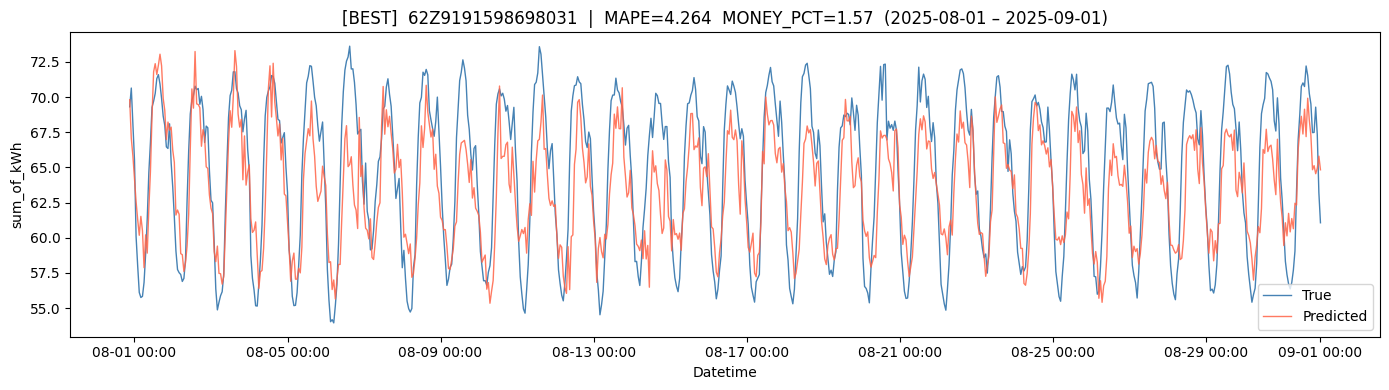

Worst station (SMAPE): 62Z0101426517156


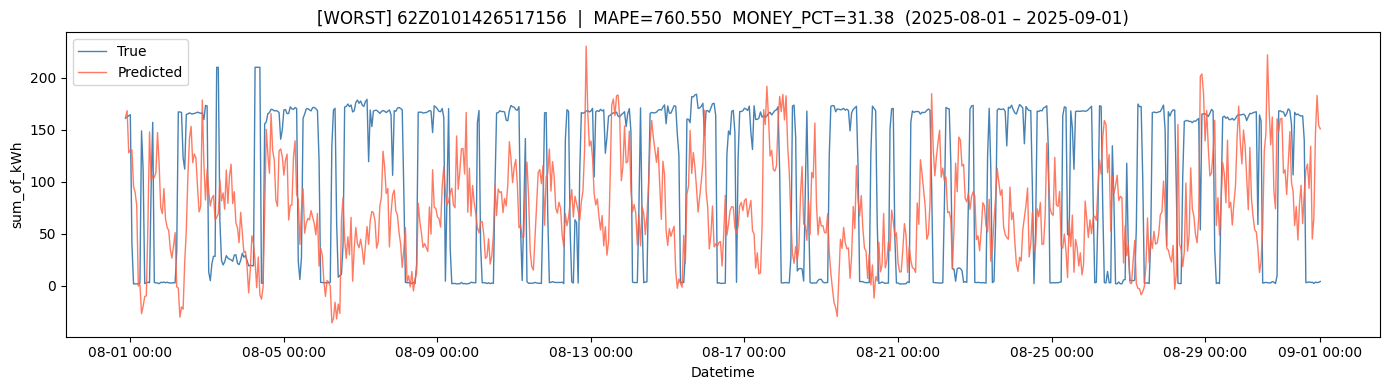

In [16]:
best_station  = test_station_metrics.iloc[0][GROUP_COL]
worst_station = test_station_metrics.iloc[-1][GROUP_COL]

print(f"Best  station (SMAPE): {best_station}")
plot_forecast(test_eval, eic_code=best_station,  title_prefix="[BEST]  ")

print(f"Worst station (SMAPE): {worst_station}")
plot_forecast(test_eval, eic_code=worst_station, title_prefix="[WORST] ")